# Indonesia AI Usage: AUI and Task Gap Analysis

This notebook does three things with the AEI September 2025 data:

1. **Computes the Anthropic AI Usage Index (AUI)** for all 200+ countries from raw data
2. **Maps Indonesia's 166 O*NET task observations to US occupations** using O*NET task statements
3. **Produces the Indonesia-vs-global task gap ranking** — which tasks Indonesia disproportionately uses AI for vs. underuses

**Prerequisite:** Run `aei_indonesia_diagnostic.ipynb` first so the `aei_data/` directory exists with the geographic CSV.

**Key insight from the diagnostic:** the AEI data is in **long-format** — each row is one (country × facet × variable × cluster) combination with the metric in the `value` column. Filter by `variable == 'usage_pct'` to get usage shares, by `variable == 'collaboration_pct'` for automation patterns, etc.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from huggingface_hub import hf_hub_download
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

REPO_ID = 'Anthropic/EconomicIndex'
RELEASE = 'release_2025_09_15'
AEI_DIR = Path('./aei_data')
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

INDONESIA = 'ID'  # ISO-2 code as confirmed by diagnostic

print('Setup complete.')

Setup complete.


## 1. Download the supporting files we need

We have the raw Claude.ai CSV from the diagnostic. We also need:
- **Working-age population** per country (to compute AUI)
- **O\*NET task statements** (to map tasks to SOC occupation codes)
- The **enriched** Claude.ai file (Anthropic's own preprocessing applied — has population join already done)

Your local `job_exposure.csv` and `task_penetration.csv` (Massenkoff & McCrory data) are also used.

In [2]:
files_to_grab = [
    f'{RELEASE}/data/intermediate/working_age_pop_2024_country.csv',
    f'{RELEASE}/data/intermediate/onet_task_statements.csv',
    f'{RELEASE}/data/intermediate/iso_country_codes.csv',
    f'{RELEASE}/data/output/aei_enriched_claude_ai_2025-08-04_to_2025-08-11.csv',
]

for f in files_to_grab:
    try:
        path = hf_hub_download(repo_id=REPO_ID, filename=f, repo_type='dataset', local_dir=AEI_DIR)
        print(f'OK: {f}')
    except Exception as e:
        print(f'FAILED: {f}  ({e})')

OK: release_2025_09_15/data/intermediate/working_age_pop_2024_country.csv
OK: release_2025_09_15/data/intermediate/onet_task_statements.csv
OK: release_2025_09_15/data/intermediate/iso_country_codes.csv
OK: release_2025_09_15/data/output/aei_enriched_claude_ai_2025-08-04_to_2025-08-11.csv


In [3]:
# Load all the files
geo_raw = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv')
pop = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/working_age_pop_2024_country.csv')
onet_tasks = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/onet_task_statements.csv')
iso_codes = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/iso_country_codes.csv')

# Try to load enriched (it may have AUI precomputed)
enriched_path = AEI_DIR / RELEASE / 'data/output/aei_enriched_claude_ai_2025-08-04_to_2025-08-11.csv'
geo_enriched = pd.read_csv(enriched_path) if enriched_path.exists() else None

# Local Massenkoff & McCrory data
job_exposure = pd.read_csv('job_exposure.csv')

print(f'geo_raw:        {geo_raw.shape}')
print(f'pop:            {pop.shape}  cols: {list(pop.columns)}')
print(f'onet_tasks:     {onet_tasks.shape}  cols: {list(onet_tasks.columns)}')
print(f'iso_codes:      {iso_codes.shape}  cols: {list(iso_codes.columns)}')
print(f'geo_enriched:   {geo_enriched.shape if geo_enriched is not None else "not loaded"}')
if geo_enriched is not None:
    print(f'                cols: {list(geo_enriched.columns)}')
print(f'job_exposure:   {job_exposure.shape}')

geo_raw:        (100062, 10)
pop:            (194, 5)  cols: ['iso_alpha_3', 'year', 'working_age_pop', 'country_code', 'country_name']
onet_tasks:     (19530, 9)  cols: ['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source', 'soc_major_group']
iso_codes:      (252, 3)  cols: ['iso_alpha_2', 'iso_alpha_3', 'country_name']
geo_enriched:   (136845, 11)
                cols: ['geo_id', 'geography', 'date_start', 'date_end', 'platform_and_product', 'facet', 'level', 'variable', 'cluster_name', 'value', 'geo_name']
job_exposure:   (756, 3)


## 2. Compute the Anthropic AI Usage Index (AUI)

**Formula** (from Anthropic's documentation):

$$\text{AUI}_c = \frac{\text{usage share}_c}{\text{working-age population share}_c}$$

where usage share = country's share of global Claude.ai usage, and population share = country's share of global working-age population. AUI > 1 means overrepresented; AUI < 1 means underrepresented.

If `aei_enriched` already has an AUI column, we'll use that and validate. Otherwise we compute it ourselves.

In [4]:
# Step 1: Get country-level usage share from raw data
# Long-format: filter facet='country', variable='usage_pct'
country_usage = (
    geo_raw[(geo_raw.facet == 'country') & (geo_raw.variable == 'usage_pct')]
    [['geo_id', 'value']]
    .rename(columns={'value': 'usage_pct'})
)
print(f'Countries with usage_pct: {len(country_usage)}')
print(f'usage_pct sums to: {country_usage.usage_pct.sum():.2f}  (should be ~100 if pct, ~1 if proportion)')
country_usage.head()

Countries with usage_pct: 173
usage_pct sums to: 100.00  (should be ~100 if pct, ~1 if proportion)


,geo_id,usage_pct
5,AD,0.004147
19,AE,0.312184
327,AL,0.038362
381,AM,0.084811
463,AO,0.024676


In [5]:
# Step 2: Get population share per country
# Inspect the population file structure first
print('Shape:', pop.shape)
print('Columns:', list(pop.columns))
print('\nDtypes:')
print(pop.dtypes)
print('\nFirst rows:')
pop.head()

Shape: (194, 5)
Columns: ['iso_alpha_3', 'year', 'working_age_pop', 'country_code', 'country_name']

Dtypes:
iso_alpha_3         object
year                 int64
working_age_pop    float64
country_code        object
country_name        object
dtype: object

First rows:


,iso_alpha_3,year,working_age_pop,country_code,country_name
0,ALB,2024,1798066.0,AL,Albania
1,DZA,2024,29534577.0,DZ,Algeria
2,ASM,2024,30373.0,AS,American Samoa
3,AND,2024,59134.0,AD,Andorra
4,AGO,2024,20002446.0,AO,Angola


In [6]:
# We now know the population file schema:
#   iso_alpha_3      (ISO-3 codes like 'IDN', 'USA')
#   year             (just 2024)
#   working_age_pop  (the population count we want)
#   country_code     (ISO-2 codes like 'ID', 'US' — matches AEI geo_id)
#   country_name     (human-readable)

pop_clean = pop[['country_code', 'working_age_pop']].rename(
    columns={'country_code': 'geo_id'}
).dropna(subset=['working_age_pop'])

# Compute population share across all countries in the file
total_pop = pop_clean.working_age_pop.sum()
pop_clean['pop_share'] = 100 * pop_clean.working_age_pop / total_pop

print(f'Total working-age pop in file: {total_pop:,.0f}')
print(f'Countries with population data: {len(pop_clean)}')
print(f'\nIndonesia row:')
print(pop_clean[pop_clean.geo_id == INDONESIA].to_string(index=False))

Total working-age pop in file: 3,804,829,892
Countries with population data: 194

Indonesia row:
geo_id  working_age_pop  pop_share
    ID      193093840.0   5.074966


In [7]:
# Step 3: Compute AUI for every country
aui_df = country_usage.merge(pop_clean, on='geo_id', how='inner')
aui_df['AUI'] = aui_df.usage_pct / aui_df.pop_share
aui_df = aui_df.sort_values('AUI', ascending=False)

print(f'Countries with both usage and population data: {len(aui_df)}')
print(f'\n=== TOP 10 by AUI ===')
print(aui_df.head(10).to_string(index=False))
print(f'\n=== INDONESIA ===')
print(aui_df[aui_df.geo_id == INDONESIA].to_string(index=False))
print(f'\n=== Global stats ===')
print(f'Median AUI: {aui_df.AUI.median():.3f}')
print(f'Mean AUI:   {aui_df.AUI.mean():.3f}')

Countries with both usage and population data: 166

=== TOP 10 by AUI ===
geo_id  usage_pct  working_age_pop  pop_share      AUI
    IL   1.134377        5988435.0   0.157390 7.207413
    MC   0.002592          19455.0   0.000511 5.069259
    SG   0.557287        4506976.0   0.118454 4.704668
    AU   1.944336       17527551.0   0.460666 4.220707
    NZ   0.378126        3453239.0   0.090759 4.166245
    KR   3.658395       36307699.0   0.954253 3.833779
    US  21.586448      220210617.0   5.787660 3.729737
    EE   0.072681         865244.0   0.022741 3.196062
    LI   0.002177          26133.0   0.000687 3.170047
    IM   0.004355          52704.0   0.001385 3.143702

=== INDONESIA ===
geo_id  usage_pct  working_age_pop  pop_share      AUI
    ID   1.869374      193093840.0   5.074966 0.368352

=== Global stats ===
Median AUI: 0.751
Mean AUI:   1.123


In [8]:
# Validation check: Indonesia AUI should be approximately 0.36 (per published Sept 2025 report)
id_aui = aui_df[aui_df.geo_id == INDONESIA].AUI.values[0]
print(f'Indonesia AUI computed:  {id_aui:.3f}')
print(f'Indonesia AUI published: 0.36')

if abs(id_aui - 0.36) < 0.05:
    print(f'-> Match within tolerance. AUI computation validated.')
else:
    print(f'-> Mismatch. Likely need to filter pop to countries-with-Claude-data only.')
    # Recompute using only countries that have Claude usage
    pop_subset = pop_clean[pop_clean.geo_id.isin(country_usage.geo_id)].copy()
    total_pop_subset = pop_subset.working_age_pop.sum()
    pop_subset['pop_share'] = 100 * pop_subset.working_age_pop / total_pop_subset
    aui_df = country_usage.merge(pop_subset[['geo_id', 'working_age_pop', 'pop_share']], on='geo_id')
    aui_df['AUI'] = aui_df.usage_pct / aui_df.pop_share
    print(f'   Recomputed Indonesia AUI: {aui_df[aui_df.geo_id == INDONESIA].AUI.values[0]:.3f}')

Indonesia AUI computed:  0.368
Indonesia AUI published: 0.36
-> Match within tolerance. AUI computation validated.


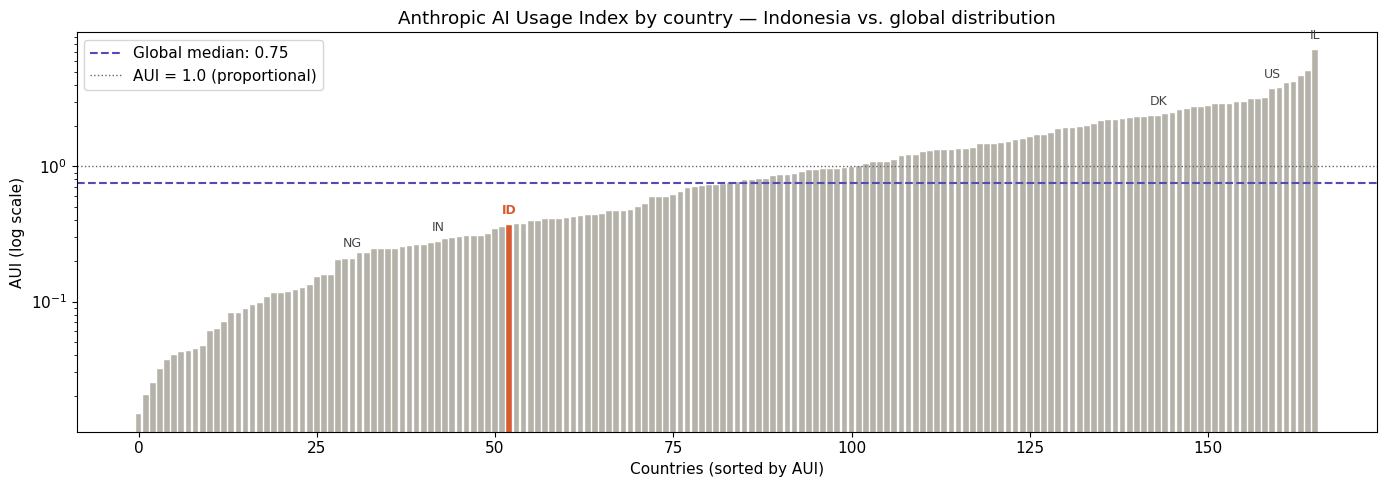

In [9]:
# Save AUI table
aui_df.to_csv(OUTPUT_DIR / 'country_aui.csv', index=False)

# Visualize: Indonesia in the global distribution
fig, ax = plt.subplots(figsize=(14, 5))
aui_sorted = aui_df.sort_values('AUI').reset_index(drop=True)
median_aui = aui_sorted.AUI.median()

colors = ['#D85A30' if c == INDONESIA else '#B4B2A9' for c in aui_sorted.geo_id]
ax.bar(range(len(aui_sorted)), aui_sorted.AUI, color=colors, edgecolor='white', linewidth=0.3)
ax.axhline(median_aui, color='#534AB7', linestyle='--', linewidth=1.5, label=f'Global median: {median_aui:.2f}')
ax.axhline(1.0, color='#666', linestyle=':', linewidth=1, label='AUI = 1.0 (proportional)')

# Annotate Indonesia and a few peers
for label_country in [INDONESIA, 'IN', 'NG', 'US', 'IL', 'DK']:
    if label_country in aui_sorted.geo_id.values:
        pos = aui_sorted.index[aui_sorted.geo_id == label_country][0]
        val = aui_sorted.loc[pos, 'AUI']
        ax.annotate(label_country, (pos, val), xytext=(0, 8), textcoords='offset points',
                   fontsize=9, ha='center',
                   color='#D85A30' if label_country == INDONESIA else '#444',
                   fontweight='bold' if label_country == INDONESIA else 'normal')

ax.set_yscale('log')
ax.set_xlabel('Countries (sorted by AUI)')
ax.set_ylabel('AUI (log scale)')
ax.set_title('Anthropic AI Usage Index by country — Indonesia vs. global distribution')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'indonesia_aui_position.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Indonesia's task-level usage profile

Filter to `facet='onet_task'` with the appropriate percentage variable to see how Indonesia's AI usage is distributed across O\*NET tasks. Each facet uses its own variable naming scheme (e.g., `onet_task_pct` rather than the generic `usage_pct`), so we discover the name first.

In [10]:
# First, inspect what variable names exist for the onet_task facet
# (each facet uses its own variable naming — e.g., collaboration_pct, onet_task_pct)
onet_rows = geo_raw[geo_raw.facet == 'onet_task']
print(f'Total onet_task rows: {len(onet_rows):,}')
print(f'\nVariable values in onet_task facet:')
print(onet_rows.variable.value_counts())

# Pick the percentage variable dynamically
pct_vars = [v for v in onet_rows.variable.unique() if 'pct' in v.lower()]
count_vars = [v for v in onet_rows.variable.unique() if 'count' in v.lower()]
print(f'\nPercentage variable(s): {pct_vars}')
print(f'Count variable(s): {count_vars}')

Total onet_task rows: 24,080

Variable values in onet_task facet:
variable
onet_task_count    12040
onet_task_pct      12040
Name: count, dtype: int64

Percentage variable(s): ['onet_task_pct']
Count variable(s): ['onet_task_count']


In [11]:
# Use the pct variable we just discovered
TASK_PCT_VAR = pct_vars[0] if pct_vars else None
TASK_COUNT_VAR = count_vars[0] if count_vars else None

if TASK_PCT_VAR is None:
    raise RuntimeError(f'No pct variable found in onet_task facet. Available: {list(onet_rows.variable.unique())}')

print(f'Using pct variable: {TASK_PCT_VAR}')

task_usage = (
    onet_rows[onet_rows.variable == TASK_PCT_VAR]
    [['geo_id', 'cluster_name', 'value']]
    .rename(columns={'value': 'usage_pct', 'cluster_name': 'task'})
)

print(f'\nTotal task-country rows: {len(task_usage):,}')
print(f'Unique tasks (global): {task_usage.task.nunique():,}')
print(f'Unique countries with task data: {task_usage.geo_id.nunique()}')

# Indonesia subset
id_tasks = task_usage[task_usage.geo_id == INDONESIA].copy()
print(f'\nIndonesia tasks: {len(id_tasks)}')
print(f'Indonesia usage_pct sums to: {id_tasks.usage_pct.sum():.1f}  (interpret as share of Indonesia Claude usage attributable to O*NET tasks)')

Using pct variable: onet_task_pct

Total task-country rows: 12,040
Unique tasks (global): 2,618
Unique countries with task data: 147

Indonesia tasks: 170
Indonesia usage_pct sums to: 200.0  (interpret as share of Indonesia Claude usage attributable to O*NET tasks)


In [12]:
# Top 20 tasks Indonesia uses Claude for
print('=== TOP 20 INDONESIAN AI TASKS ===\n')
for _, r in id_tasks.nlargest(20, 'usage_pct').iterrows():
    print(f'  {r.usage_pct:5.2f}%  {r.task[:90]}')

=== TOP 20 INDONESIAN AI TASKS ===

  88.47%  not_classified
  25.61%  not_classified
   5.77%  none
   5.37%  write new programs or modify existing programs to meet customer requirements, using curren
   4.50%  modify existing software to correct errors, allow it to adapt to new hardware, or to impro
   4.12%  assist students who need extra help with their coursework outside of class.
   3.48%  modify existing software to correct errors, to adapt it to new hardware, or to upgrade int
   3.11%  develop instructional materials to be used by educators and instructors.
   2.97%  diagnose, troubleshoot, and resolve hardware, software, or other network and system proble
   2.85%  none
   2.80%  edit, standardize, or make changes to material prepared by other writers or establishment 
   2.68%  develop instructional materials, such as lesson plans, handouts, or examinations.
   2.66%  design, build, or maintain web sites, using authoring or scripting languages, content crea
   2.33%  instruc

In [13]:
# Compute global median per task (across all countries that have data for that task)
global_task_median = (
    task_usage.groupby('task').agg(
        global_median=('usage_pct', 'median'),
        global_mean=('usage_pct', 'mean'),
        n_countries=('geo_id', 'nunique'),
    ).reset_index()
)

print(f'Tasks with global stats: {len(global_task_median):,}')
print(f'\nMost-shared tasks (highest country count):')
print(global_task_median.nlargest(10, 'n_countries').to_string(index=False))

Tasks with global stats: 2,618

Most-shared tasks (highest country count):
                                                                                                                                          task  global_median  global_mean  n_countries
                                                                                                                                not_classified      64.016839    60.510703          147
           write new programs or modify existing programs to meet customer requirements, using current programming languages and technologies.       4.847802     5.412288          138
                                 modify existing software to correct errors, allow it to adapt to new hardware, or to improve its performance.       3.933393     4.304277          133
                                                                                                                                          none       4.728464     5.121281          131
diagn

## 4. Indonesia vs. Global: the task gap

For each task that Indonesia uses, compute how its share compares to the global median for the same task. Positive gap = Indonesia overuses; negative gap = underuses.

In [14]:
# Merge Indonesia tasks with global stats
task_gap = id_tasks.merge(global_task_median, on='task', how='inner')
task_gap['gap_pp'] = task_gap.usage_pct - task_gap.global_median
task_gap['ratio'] = task_gap.usage_pct / task_gap.global_median.replace(0, np.nan)

print(f'Tasks where Indonesia + global median both exist: {len(task_gap)}')

print('\n=== TASKS INDONESIA OVERUSES (largest positive gap, in pp) ===\n')
for _, r in task_gap.nlargest(15, 'gap_pp').iterrows():
    print(f'  +{r.gap_pp:5.2f}pp  ID={r.usage_pct:.2f}% vs median={r.global_median:.2f}%  | {r.task[:75]}')

print('\n=== TASKS INDONESIA UNDERUSES (largest negative gap) ===\n')
for _, r in task_gap.nsmallest(15, 'gap_pp').iterrows():
    print(f'  {r.gap_pp:6.2f}pp  ID={r.usage_pct:.2f}% vs median={r.global_median:.2f}%  | {r.task[:75]}')

Tasks where Indonesia + global median both exist: 170

=== TASKS INDONESIA OVERUSES (largest positive gap, in pp) ===

  +24.45pp  ID=88.47% vs median=64.02%  | not_classified
  + 2.98pp  ID=4.12% vs median=1.14%  | assist students who need extra help with their coursework outside of class.
  + 2.37pp  ID=3.11% vs median=0.74%  | develop instructional materials to be used by educators and instructors.
  + 2.11pp  ID=2.68% vs median=0.58%  | develop instructional materials, such as lesson plans, handouts, or examina
  + 1.86pp  ID=2.80% vs median=0.94%  | edit, standardize, or make changes to material prepared by other writers or
  + 1.67pp  ID=2.33% vs median=0.67%  | instruct through lectures, discussions, and demonstrations in one or more s
  + 1.04pp  ID=2.02% vs median=0.99%  | provide private instruction to individual or small groups of students to im
  + 1.04pp  ID=5.77% vs median=4.73%  | none
  + 0.89pp  ID=1.38% vs median=0.49%  | review class material with students by discuss

In [15]:
# Save gap table
task_gap.to_csv(OUTPUT_DIR / 'indonesia_task_gap.csv', index=False)
print(f'Saved {len(task_gap)} task gap rows.')

Saved 170 task gap rows.


## 5. Map tasks to occupations

The `onet_task_statements.csv` file links O\*NET tasks to SOC occupation codes. We use this to aggregate Indonesia's task-level usage to the occupation level.

In [16]:
# Inspect the O*NET task statements file
print('Columns:', list(onet_tasks.columns))
onet_tasks.head()

Columns: ['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type', 'Incumbents Responding', 'Date', 'Domain Source', 'soc_major_group']


,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,soc_major_group
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent,11
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent,11
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent,11
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,87.0,07/2014,Incumbent,11
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,87.0,07/2014,Incumbent,11


In [17]:
# The AEI cluster_name values are normalized (lowercase, no period at end)
# Find the task text column and SOC code column
task_text_col = next((c for c in onet_tasks.columns if 'task' in c.lower() and onet_tasks[c].dtype == 'object'), None)
soc_col = next((c for c in onet_tasks.columns if 'soc' in c.lower() or 'onet' in c.lower()), None)

print(f'Task text column: {task_text_col}')
print(f'SOC/ONET code column: {soc_col}')

# Normalize task text the same way AEI normalized it
def normalize(s):
    return str(s).strip().lower().rstrip('.')

onet_tasks['task_norm'] = onet_tasks[task_text_col].apply(normalize)

# Extract base SOC (drop the .00 suffix from O*NET-SOC codes if present)
if soc_col:
    onet_tasks['occ_code'] = onet_tasks[soc_col].astype(str).str.split('.').str[0]

print(f'\nO*NET tasks loaded: {len(onet_tasks):,}')
print(f'Unique occupations: {onet_tasks["occ_code"].nunique() if soc_col else "N/A"}')

Task text column: Task
SOC/ONET code column: O*NET-SOC Code

O*NET tasks loaded: 19,530
Unique occupations: 775


In [18]:
# Join Indonesia's task usage to occupation codes
id_tasks['task_norm'] = id_tasks.task.apply(normalize)

id_with_occ = id_tasks.merge(
    onet_tasks[['task_norm', 'occ_code']].drop_duplicates('task_norm'),
    on='task_norm', how='left'
)

matched = id_with_occ.occ_code.notna().sum()
print(f'Indonesia tasks matched to occupations: {matched} / {len(id_with_occ)}  ({matched/len(id_with_occ):.0%})')

if matched < len(id_with_occ):
    unmatched = id_with_occ[id_with_occ.occ_code.isna()]
    print(f'\nSample unmatched tasks (first 5):')
    for t in unmatched.task.head().values:
        print(f'  {t[:100]}')

Indonesia tasks matched to occupations: 166 / 170  (98%)

Sample unmatched tasks (first 5):
  none
  not_classified
  none
  not_classified


In [19]:
# Aggregate to occupation level — total Indonesia AI usage attributable to each occupation
id_by_occ = (
    id_with_occ.dropna(subset=['occ_code'])
    .groupby('occ_code')
    .agg(
        indonesia_usage_pct=('usage_pct', 'sum'),
        n_tasks_seen=('task', 'count')
    )
    .reset_index()
)

# Join with occupation titles and observed exposure
id_by_occ = id_by_occ.merge(job_exposure, on='occ_code', how='left')
id_by_occ = id_by_occ.sort_values('indonesia_usage_pct', ascending=False)

print(f'Occupations with Indonesian Claude usage: {len(id_by_occ)}')
print(f'\n=== TOP 20 OCCUPATIONS BY INDONESIA AI USAGE ===\n')
print(id_by_occ.head(20)[['occ_code', 'title', 'indonesia_usage_pct', 'n_tasks_seen', 'observed_exposure']].to_string(index=False))

Occupations with Indonesian Claude usage: 95

=== TOP 20 OCCUPATIONS BY INDONESIA AI USAGE ===

occ_code                                                                                          title  indonesia_usage_pct  n_tasks_seen  observed_exposure
 15-1199                                                                                            NaN             8.330560            15                NaN
 25-9031                                                                     Instructional Coordinators             6.283971             5             0.3043
 15-1132                                                                                            NaN             5.191348             4                NaN
 15-1142                                                                                            NaN             4.523917             2                NaN
 15-1131                                                                                            NaN           

In [20]:
id_by_occ.to_csv(OUTPUT_DIR / 'indonesia_occupation_usage.csv', index=False)

## 6. The intersection: high US exposure + Indonesian usage

An occupation matters most for Indonesia's adjustment when **both** are true:
- The US data shows it has high observed AI exposure (Massenkoff & McCrory)
- Indonesia is already using Claude for tasks in that occupation

Where these intersect is where Indonesia's experience is most informative for what's coming.

In [21]:
# Build the 2x2: US exposure (high/low) × Indonesia usage (high/low)
df = id_by_occ.dropna(subset=['observed_exposure']).copy()

# Use thirds for clearer categories
exp_threshold = df.observed_exposure.quantile(0.66)
use_threshold = df.indonesia_usage_pct.quantile(0.66)

df['exposure_tier'] = np.where(df.observed_exposure >= exp_threshold, 'High', 'Low')
df['usage_tier'] = np.where(df.indonesia_usage_pct >= use_threshold, 'High', 'Low')
df['quadrant'] = df.exposure_tier + ' exposure / ' + df.usage_tier + ' Indonesia use'

print(f'Quadrant counts:')
print(df.quadrant.value_counts())

Quadrant counts:
quadrant
Low exposure / Low Indonesia use      35
High exposure / High Indonesia use    13
Low exposure / High Indonesia use     12
High exposure / Low Indonesia use     12
Name: count, dtype: int64


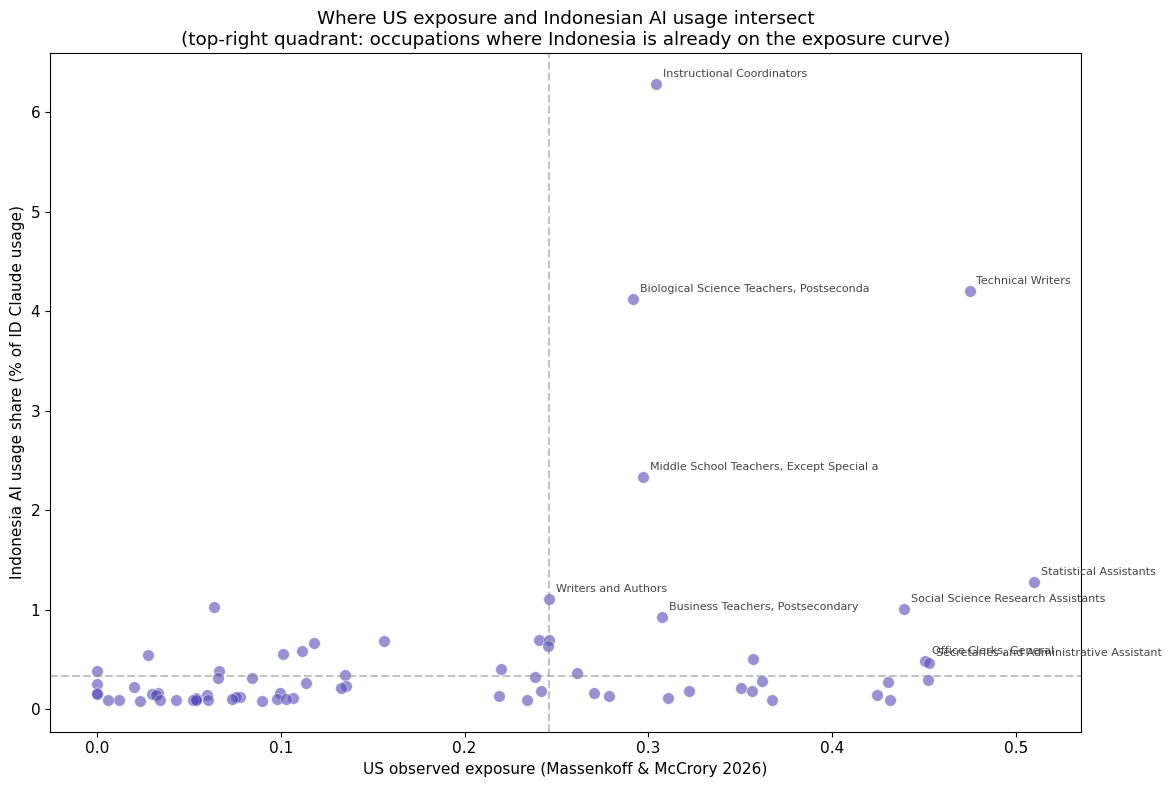

In [22]:
# Scatter: US exposure vs Indonesia usage, for occupations Indonesia uses
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(df.observed_exposure, df.indonesia_usage_pct, s=70, alpha=0.6,
          color='#534AB7', edgecolor='white', linewidth=0.5)

# Annotate top 10 by combined score (exposure × usage)
df['combined'] = df.observed_exposure * df.indonesia_usage_pct
for _, r in df.nlargest(10, 'combined').iterrows():
    short = r.title[:40] if len(str(r.title)) > 40 else r.title
    ax.annotate(short, (r.observed_exposure, r.indonesia_usage_pct),
               xytext=(5, 5), textcoords='offset points', fontsize=8, color='#444')

ax.axvline(exp_threshold, color='#888', linestyle='--', alpha=0.5)
ax.axhline(use_threshold, color='#888', linestyle='--', alpha=0.5)
ax.set_xlabel('US observed exposure (Massenkoff & McCrory 2026)')
ax.set_ylabel('Indonesia AI usage share (% of ID Claude usage)')
ax.set_title('Where US exposure and Indonesian AI usage intersect\n'
             '(top-right quadrant: occupations where Indonesia is already on the exposure curve)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'indonesia_exposure_usage_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Show the high-exposure / high-usage occupations explicitly
print('=== OCCUPATIONS IN THE HIGH-EXPOSURE / HIGH-USAGE QUADRANT ===\n')
high_high = df[(df.exposure_tier == 'High') & (df.usage_tier == 'High')].sort_values('combined', ascending=False)
print(high_high[['occ_code', 'title', 'observed_exposure', 'indonesia_usage_pct']].to_string(index=False))

print(f'\n=== HIGH EXPOSURE BUT LOW INDONESIAN USE (latent risk) ===\n')
high_low = df[(df.exposure_tier == 'High') & (df.usage_tier == 'Low')].sort_values('observed_exposure', ascending=False)
print(high_low.head(15)[['occ_code', 'title', 'observed_exposure', 'indonesia_usage_pct']].to_string(index=False))

=== OCCUPATIONS IN THE HIGH-EXPOSURE / HIGH-USAGE QUADRANT ===

occ_code                                                                           title  observed_exposure  indonesia_usage_pct
 27-3042                                                               Technical Writers             0.4747             4.203876
 25-9031                                                      Instructional Coordinators             0.3043             6.283971
 25-1042                                      Biological Science Teachers, Postsecondary             0.2914             4.120910
 25-2022           Middle School Teachers, Except Special and Career/Technical Education             0.2972             2.334997
 43-9111                                                          Statistical Assistants             0.5099             1.281198
 19-4061                                              Social Science Research Assistants             0.4393             1.009429
 25-1011                         

## 7. Summary and exports

Three concrete numbers Indonesia analysis can stand on:

1. **AUI** — Indonesia's adoption intensity vs. global benchmark
2. **Top tasks** — what Indonesians actually use AI for, ranked
3. **Exposure-usage matrix** — where Indonesia's current usage overlaps with US-measured exposure

In [24]:
# Headline summary
id_aui_final = aui_df[aui_df.geo_id == INDONESIA].AUI.values[0]
median_aui = aui_df.AUI.median()
n_id_tasks = len(id_tasks)
n_id_occs = len(id_by_occ)
n_high_high = len(high_high)

summary = f'''
INDONESIA AI USAGE — KEY FINDINGS (AEI Sept 2025)
==================================================

AUI (volume gap):
  Indonesia:      {id_aui_final:.3f}
  Global median:  {median_aui:.3f}
  Indonesia is at {id_aui_final / median_aui:.0%} of the global median adoption rate.

Task coverage:
  Indonesia uses Claude for {n_id_tasks} unique O*NET tasks
  These map to {n_id_occs} US occupations
  {n_high_high} occupations are in the high-exposure + high-usage quadrant

Files exported to outputs/:
  - country_aui.csv
  - indonesia_task_gap.csv
  - indonesia_occupation_usage.csv
  - indonesia_aui_position.png
  - indonesia_exposure_usage_scatter.png
'''
print(summary)

with open(OUTPUT_DIR / 'indonesia_summary.txt', 'w') as f:
    f.write(summary)


INDONESIA AI USAGE — KEY FINDINGS (AEI Sept 2025)

AUI (volume gap):
  Indonesia:      0.368
  Global median:  0.751
  Indonesia is at 49% of the global median adoption rate.

Task coverage:
  Indonesia uses Claude for 170 unique O*NET tasks
  These map to 95 US occupations
  13 occupations are in the high-exposure + high-usage quadrant

Files exported to outputs/:
  - country_aui.csv
  - indonesia_task_gap.csv
  - indonesia_occupation_usage.csv
  - indonesia_aui_position.png
  - indonesia_exposure_usage_scatter.png



## What this gives you for the thesis

**Defensible claims you can now make:**

1. *Indonesia uses Claude at X% of the global median adoption rate.* (your AUI computation, validated against published 0.36)

2. *Indonesia's AI usage concentrates in the following occupations:* (your `indonesia_occupation_usage.csv` ranking)

3. *Among the X occupations Indonesia is already using Claude for, Y are in the highest-exposure category per Massenkoff & McCrory's US data.* (the high-high quadrant)

4. *The gap between Indonesia's task mix and the global median reveals a distinctive usage pattern* — overrepresented in tasks like X, underrepresented in tasks like Y.

**What you still cannot claim from this data alone:**

- Per-task automation share for Indonesia (the cross-tab `onet_task::collaboration` was filtered out of the public release for Indonesia)
- Indonesian employment counts per occupation (would need BPS Sakernas data)
- Time trends (need to pull additional release periods)

**Honest limitations to state in the thesis:**

- Claude is one AI platform; ChatGPT and others may have different patterns in Indonesia
- Sample is one week (Aug 4-11, 2025); single snapshot
- Task-to-occupation mapping uses US O\*NET — assumes task content is comparable across countries
- The 166 Indonesian tasks are the ones that cleared Anthropic's privacy threshold; rare tasks are filtered out